# Minimum Eigenvalue Control Laws for Separatrix Following

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy import linalg
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')
import datetime

In [98]:
class VectorField:
    def __init__(self):
        self.vortex1_pos = np.array([-2, 0])
        self.vortex2_pos = np.array([2, 0])
        
    def evaluate(self, x, y):
        x1, y1 = self.vortex1_pos
        vx1 = -(y - y1)
        vy1 = (x - x1)
        
        x2, y2 = self.vortex2_pos
        vx2 = (y - y2)
        vy2 = -(x - x2)

        d1 = np.sqrt((x - x1)**2 + (y - y1)**2)
        d2 = np.sqrt((x - x2)**2 + (y - y2)**2)
        w1 = 1.0 / (d1**2 + 0.1)
        w2 = 1.0 / (d2**2 + 0.1)
        vx = (vx1 * w1 + vx2 * w2) / (w1 + w2)
        vy = (vy1 * w1 + vy2 * w2) / (w1 + w2)
        return np.array([10*vx, 10*vy])
    
    def jacobian_twosided(self, x, y, h=0.01):
        fx_plus, fy_plus = self.evaluate(x + h, y)
        fx_minus, fy_minus = self.evaluate(x - h, y)
        fx_yplus, fy_yplus = self.evaluate(x, y + h)
        fx_yminus, fy_yminus = self.evaluate(x, y - h)
        
        J = np.array([
            [(fx_plus - fx_minus) / (2*h), (fx_yplus - fx_yminus) / (2*h)],
            [(fy_plus - fy_minus) / (2*h), (fy_yplus - fy_yminus) / (2*h)]
        ])
        return J

In [99]:
class RobotCluster4:
    def __init__(self, num_robots=4, formation_radius=2):
        self.num_robots = num_robots
        self.formation_radius = formation_radius
        self.positions = np.zeros((num_robots, 2))
        self.centroid = np.array([0.1, 2.2])
        self.vector_readings = np.zeros((num_robots, 2))
        self.formation_angle = np.random.uniform(0, 2*np.pi)
        self._update_robot_positions()
        
    def _update_robot_positions(self):
        triangle_angles = np.array([np.pi/2, np.pi/2 + 2*np.pi/3, np.pi/2 + 4*np.pi/3])
        triangle_angles = triangle_angles + self.formation_angle
        for i in range(3):
            self.positions[i] = self.centroid + self.formation_radius * np.array([np.cos(triangle_angles[i]), np.sin(triangle_angles[i])])
        self.positions[3] = self.centroid
    
    def update_readings(self, vector_field):
        for i in range(self.num_robots):
            x, y = self.positions[i]
            self.vector_readings[i] = vector_field.evaluate(x, y)
    
    def compute_jacobian(self, positions=None, readings=None):
        if positions is None:
            positions = self.positions
            readings = self.vector_readings
            
        n = len(positions)
        A = np.column_stack([positions[:, 0], positions[:, 1], np.ones(n)])
        b_u = readings[:, 0]
        b_v = readings[:, 1]
        
        try:
            coeffs_u, _, _, _ = np.linalg.lstsq(A, b_u, rcond=None)
            coeffs_v, _, _, _ = np.linalg.lstsq(A, b_v, rcond=None)
            
            J = np.array([
                [coeffs_u[0], coeffs_u[1]],
                [coeffs_v[0], coeffs_v[1]]
            ])
            return J
            
        except np.linalg.LinAlgError:
            return None
    
    def compute_min_eigenvalue_control_law1(self, output_file):
        print("\n=== CONTROL LAW 1 ===", file=output_file)
        print(f"Centroid: {self.centroid}", file=output_file)
        
        J_overall = self.compute_jacobian()
        if J_overall is None:
            print("Failed to compute overall Jacobian", file=output_file)
            return np.array([0.0, 0.0])
        
        eigvals_overall = np.linalg.eigvals(J_overall)
        min_eig_overall = np.min(np.abs(eigvals_overall))
        print(f"Overall Jacobian eigenvalues: {eigvals_overall}", file=output_file)
        print(f"Overall min eigenvalue magnitude: {min_eig_overall:.6f}", file=output_file)
        
        robot_combinations = list(combinations(range(4), 3))
        min_eigenvalues = []
        centroids = []
        
        for i, combo in enumerate(robot_combinations):
            pos_subset = self.positions[list(combo)]
            readings_subset = self.vector_readings[list(combo)]
            centroid_subset = np.mean(pos_subset, axis=0)
            
            J_subset = self.compute_jacobian(pos_subset, readings_subset)
            if J_subset is not None:
                eigvals = np.linalg.eigvals(J_subset)
                min_eig = np.min(np.abs(eigvals))
                min_eigenvalues.append(min_eig)
                centroids.append(centroid_subset)
                print(f"  Combo {combo}: centroid={centroid_subset}, min_eig={min_eig:.6f}", file=output_file)
        
        if len(min_eigenvalues) == 0:
            print("No valid combinations found", file=output_file)
            return np.array([0.0, 0.0])
        
        min_idx = np.argmin(min_eigenvalues)
        target_centroid = centroids[min_idx]
        correction = target_centroid - self.centroid
        
        print(f"Smallest min eigenvalue: {min_eigenvalues[min_idx]:.6f} at {target_centroid}", file=output_file)
        print(f"Correction vector: {correction}", file=output_file)
        
        return correction / np.linalg.norm(correction) if np.linalg.norm(correction) > 1e-10 else np.array([0.0, 0.0])
    
    def compute_min_eigenvalue_control_law2(self, output_file):
        print("\n=== CONTROL LAW 2 ===", file=output_file)
        print(f"Centroid: {self.centroid}", file=output_file)
        
        min_eigenvalues = []
        positions = []
        
        J_overall = self.compute_jacobian()
        if J_overall is not None:
            eigvals = np.linalg.eigvals(J_overall)
            min_eig = np.min(np.abs(eigvals))
            min_eigenvalues.append(min_eig)
            positions.append(self.centroid)
            print(f"Overall: pos={self.centroid}, min_eig={min_eig:.6f}", file=output_file)
        
        robot_combinations = list(combinations(range(4), 3))
        for combo in robot_combinations:
            pos_subset = self.positions[list(combo)]
            readings_subset = self.vector_readings[list(combo)]
            centroid_subset = np.mean(pos_subset, axis=0)
            
            J_subset = self.compute_jacobian(pos_subset, readings_subset)
            if J_subset is not None:
                eigvals = np.linalg.eigvals(J_subset)
                min_eig = np.min(np.abs(eigvals))
                min_eigenvalues.append(min_eig)
                positions.append(centroid_subset)
                print(f"  Combo {combo}: pos={centroid_subset}, min_eig={min_eig:.6f}", file=output_file)
        
        if len(positions) < 3:
            print("Not enough valid points for gradient", file=output_file)
            return np.array([0.0, 0.0])
        
        positions = np.array(positions)
        min_eigenvalues = np.array(min_eigenvalues)
        
        A_grad = np.column_stack([positions[:, 0], positions[:, 1], np.ones(len(positions))])
        
        try:
            coeffs, _, _, _ = np.linalg.lstsq(A_grad, min_eigenvalues, rcond=None)
            gradient = np.array([coeffs[0], coeffs[1]])
            
            print(f"Gradient: {gradient}", file=output_file)
            print(f"Gradient magnitude: {np.linalg.norm(gradient):.6f}", file=output_file)
            
            if np.linalg.norm(gradient) > 1e-10:
                direction = -gradient / np.linalg.norm(gradient)
            else:
                direction = np.array([0.0, 0.0])
            
            print(f"Control direction: {direction}", file=output_file)
            return direction
            
        except np.linalg.LinAlgError:
            print("Failed to compute gradient", file=output_file)
            return np.array([0.0, 0.0])
    
    def update_positions(self, delta):
        self.centroid += delta
        self._update_robot_positions()

In [100]:
def visualize_results(centroid_history, robots, vector_field, title_suffix=""):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.set_xlim(-5, 5)
    ax.set_ylim(-2, 8)
    
    x = np.linspace(-5, 5, 20)
    y = np.linspace(-2, 8, 20)
    X, Y = np.meshgrid(x, y)
    
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            U[i, j], V[i, j] = vector_field.evaluate(X[i, j], Y[i, j])
    
    magnitude = np.sqrt(U**2 + V**2)
    U = U / magnitude
    V = V / magnitude
    
    ax.quiver(X, Y, U, V, alpha=0.3, color='gray')
    
    for i, pos in enumerate(robots.positions):
        ax.scatter(pos[0], pos[1], c='blue', marker='o', s=100)
        circle = Circle(pos, 0.05, fill=False, color='blue')
        ax.add_patch(circle)
        ax.text(pos[0]+0.05, pos[1]+0.05, f'R{i+1}')
    
    ax.plot(centroid_history[:, 0], centroid_history[:, 1], 'b-', alpha=0.7, label='Cluster Path')
    ax.scatter(centroid_history[0, 0], centroid_history[0, 1], c='green', marker='o', s=100, label='Start')
    ax.scatter(centroid_history[-1, 0], centroid_history[-1, 1], c='red', marker='o', s=100, label='End')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'4-Robot Cluster - Min Eigenvalue Control {title_suffix}')
    ax.legend()
    ax.grid(True)
    
    plt.tight_layout()
    return fig

In [101]:
def simulate_min_eigenvalue_control(control_law=1, n_steps=500, step_size=0.02, 
                                   correction_weight=0.3, verbose=True, formation_radius=0.3):
    
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    output_filename = f"control_law_{control_law}_output_{timestamp}.txt"
    
    with open(output_filename, 'w') as output_file:
        print(f"\n{'='*60}", file=output_file)
        print(f"SIMULATION START - Control Law {control_law}", file=output_file)
        print(f"Parameters: n_steps={n_steps}, step_size={step_size}, correction_weight={correction_weight}", file=output_file)
        print(f"{'='*60}\n", file=output_file)
        
        vector_field = VectorField()
        robots = RobotCluster4(num_robots=4, formation_radius=1)
        
        centroid_history = np.zeros((n_steps, 2))
        
        for step in range(n_steps):
            print(f"\n--- Step {step} ---", file=output_file)
            
            centroid_history[step] = robots.centroid
            robots.update_readings(vector_field)
            
            if control_law == 1:
                correction = robots.compute_min_eigenvalue_control_law1(output_file)
            else:
                correction = robots.compute_min_eigenvalue_control_law2(output_file)
            
            J = robots.compute_jacobian()
            if J is not None:
                eigvals, eigvecs = np.linalg.eig(J)
                actual_flow = np.mean(robots.vector_readings, axis=0)
                actual_flow_norm = actual_flow / np.linalg.norm(actual_flow)
                
                eigvec1 = np.real(eigvecs[:, 0])
                eigvec2 = np.real(eigvecs[:, 1])
                eigvec1 = eigvec1 / np.linalg.norm(eigvec1)
                eigvec2 = eigvec2 / np.linalg.norm(eigvec2)
                
                dot1 = abs(np.dot(actual_flow_norm, eigvec1))
                dot2 = abs(np.dot(actual_flow_norm, eigvec2))
                
                primary_eigvec = eigvec1 if dot1 > dot2 else eigvec2
                
                if np.dot(primary_eigvec, actual_flow_norm) < 0:
                    primary_eigvec = -primary_eigvec
                
                correction_parallel = np.dot(correction, primary_eigvec) * primary_eigvec
                correction_orthogonal = correction - correction_parallel
                direction = (1 - correction_weight) * primary_eigvec + correction_weight * correction_orthogonal
                
                print(f"Primary eigenvector: {primary_eigvec}", file=output_file)
                print(f"Correction weight: {correction_weight}", file=output_file)
                print(f"Final direction: {direction}", file=output_file)
                print(f"Min eigenvalue magnitude: {np.min(np.abs(eigvals)):.6f}", file=output_file)
                
                if verbose and step % 50 == 0:
                    print(f"Step {step}: centroid = {robots.centroid}, min_eig = {np.min(np.abs(eigvals)):.6f}")
            else:
                avg_vector = np.mean(robots.vector_readings, axis=0)
                avg_vector_norm = np.linalg.norm(avg_vector)
                direction = avg_vector / avg_vector_norm if avg_vector_norm > 0 else np.array([0, 1])
                print(f"Using average flow direction: {direction}", file=output_file)
            
            robots.update_positions(step_size * direction)
        
        print(f"\n{'='*60}", file=output_file)
        print(f"SIMULATION END", file=output_file)
        print(f"Final position: {robots.centroid}", file=output_file)
        print(f"{'='*60}", file=output_file)
    
    print(f"\nOutput saved to: {output_filename}")
    return centroid_history, robots, vector_field

Testing Control Law 1 (Min eigenvalue to specific point)
Step 0: centroid = [0.1 2.2], min_eig = 2.102933
Step 50: centroid = [-0.01120076  2.82659498], min_eig = 1.514195
Step 100: centroid = [-0.10354061  3.45615614], min_eig = 1.105044
Step 150: centroid = [-0.19651279  4.0856313 ], min_eig = 0.817122
Step 200: centroid = [-0.29656117  4.71409073], min_eig = 0.614569
Step 250: centroid = [-0.40591722  5.34108972], min_eig = 0.470465
Step 300: centroid = [-0.52521386  5.96636936], min_eig = 0.366185
Step 350: centroid = [-0.65442515  6.58976769], min_eig = 0.289311
Step 400: centroid = [-0.79324682  7.21118192], min_eig = 0.231599
Step 450: centroid = [-0.94126302  7.8305483 ], min_eig = 0.187535
Step 500: centroid = [-1.09802305  8.44783002], min_eig = 0.153367
Step 550: centroid = [-1.26307729  9.06300927], min_eig = 0.126502

Output saved to: control_law_1_output_20250702_170302.txt


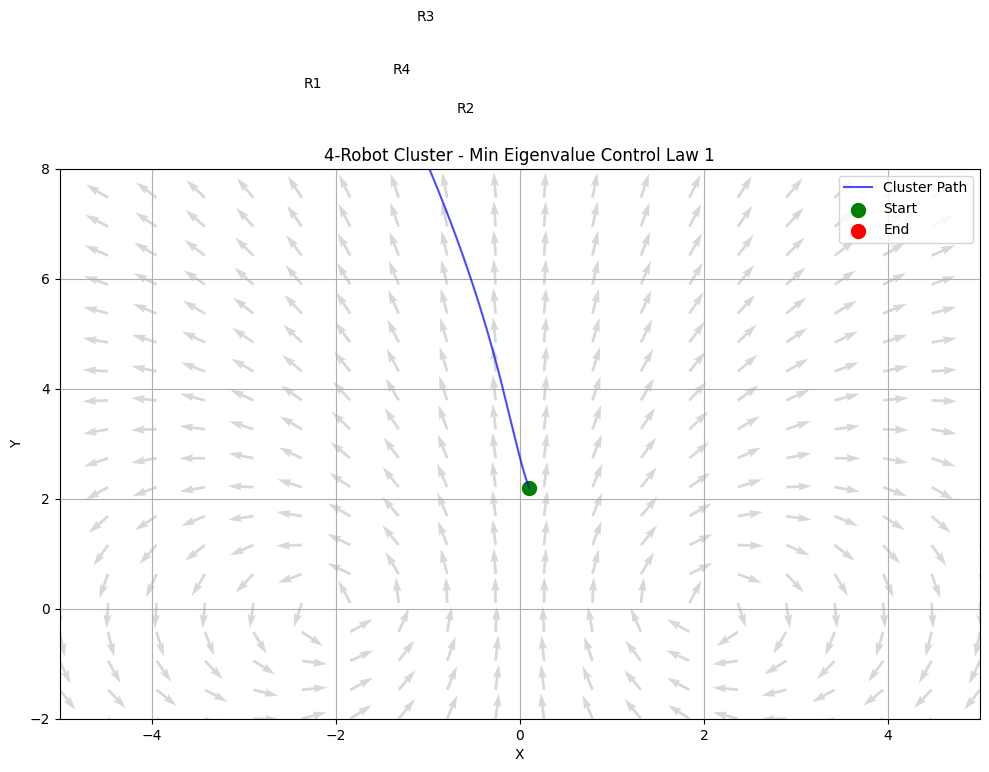



Testing Control Law 2 (Min eigenvalue gradient)
Step 0: centroid = [0.1 2.2], min_eig = 1.309835
Step 50: centroid = [0.38684516 5.33634   ], min_eig = 0.315112
Step 100: centroid = [0.89808165 8.45554948], min_eig = 0.091978
Step 150: centroid = [ 1.66419037 11.53588095], min_eig = 0.029110
Step 200: centroid = [ 2.63000874 14.56901808], min_eig = 0.006718
Step 250: centroid = [ 3.73972678 17.55600612], min_eig = 0.002157
Step 300: centroid = [ 4.94958346 20.50264105], min_eig = 0.005730
Step 350: centroid = [ 6.22879602 23.41589548], min_eig = 0.007024
Step 400: centroid = [ 7.55671962 26.30216193], min_eig = 0.007295
Step 450: centroid = [ 8.91998192 29.16662227], min_eig = 0.007104
Step 500: centroid = [10.30993338 32.01326625], min_eig = 0.006715
Step 550: centroid = [11.72086551 34.84511992], min_eig = 0.006255

Output saved to: control_law_2_output_20250702_170302.txt


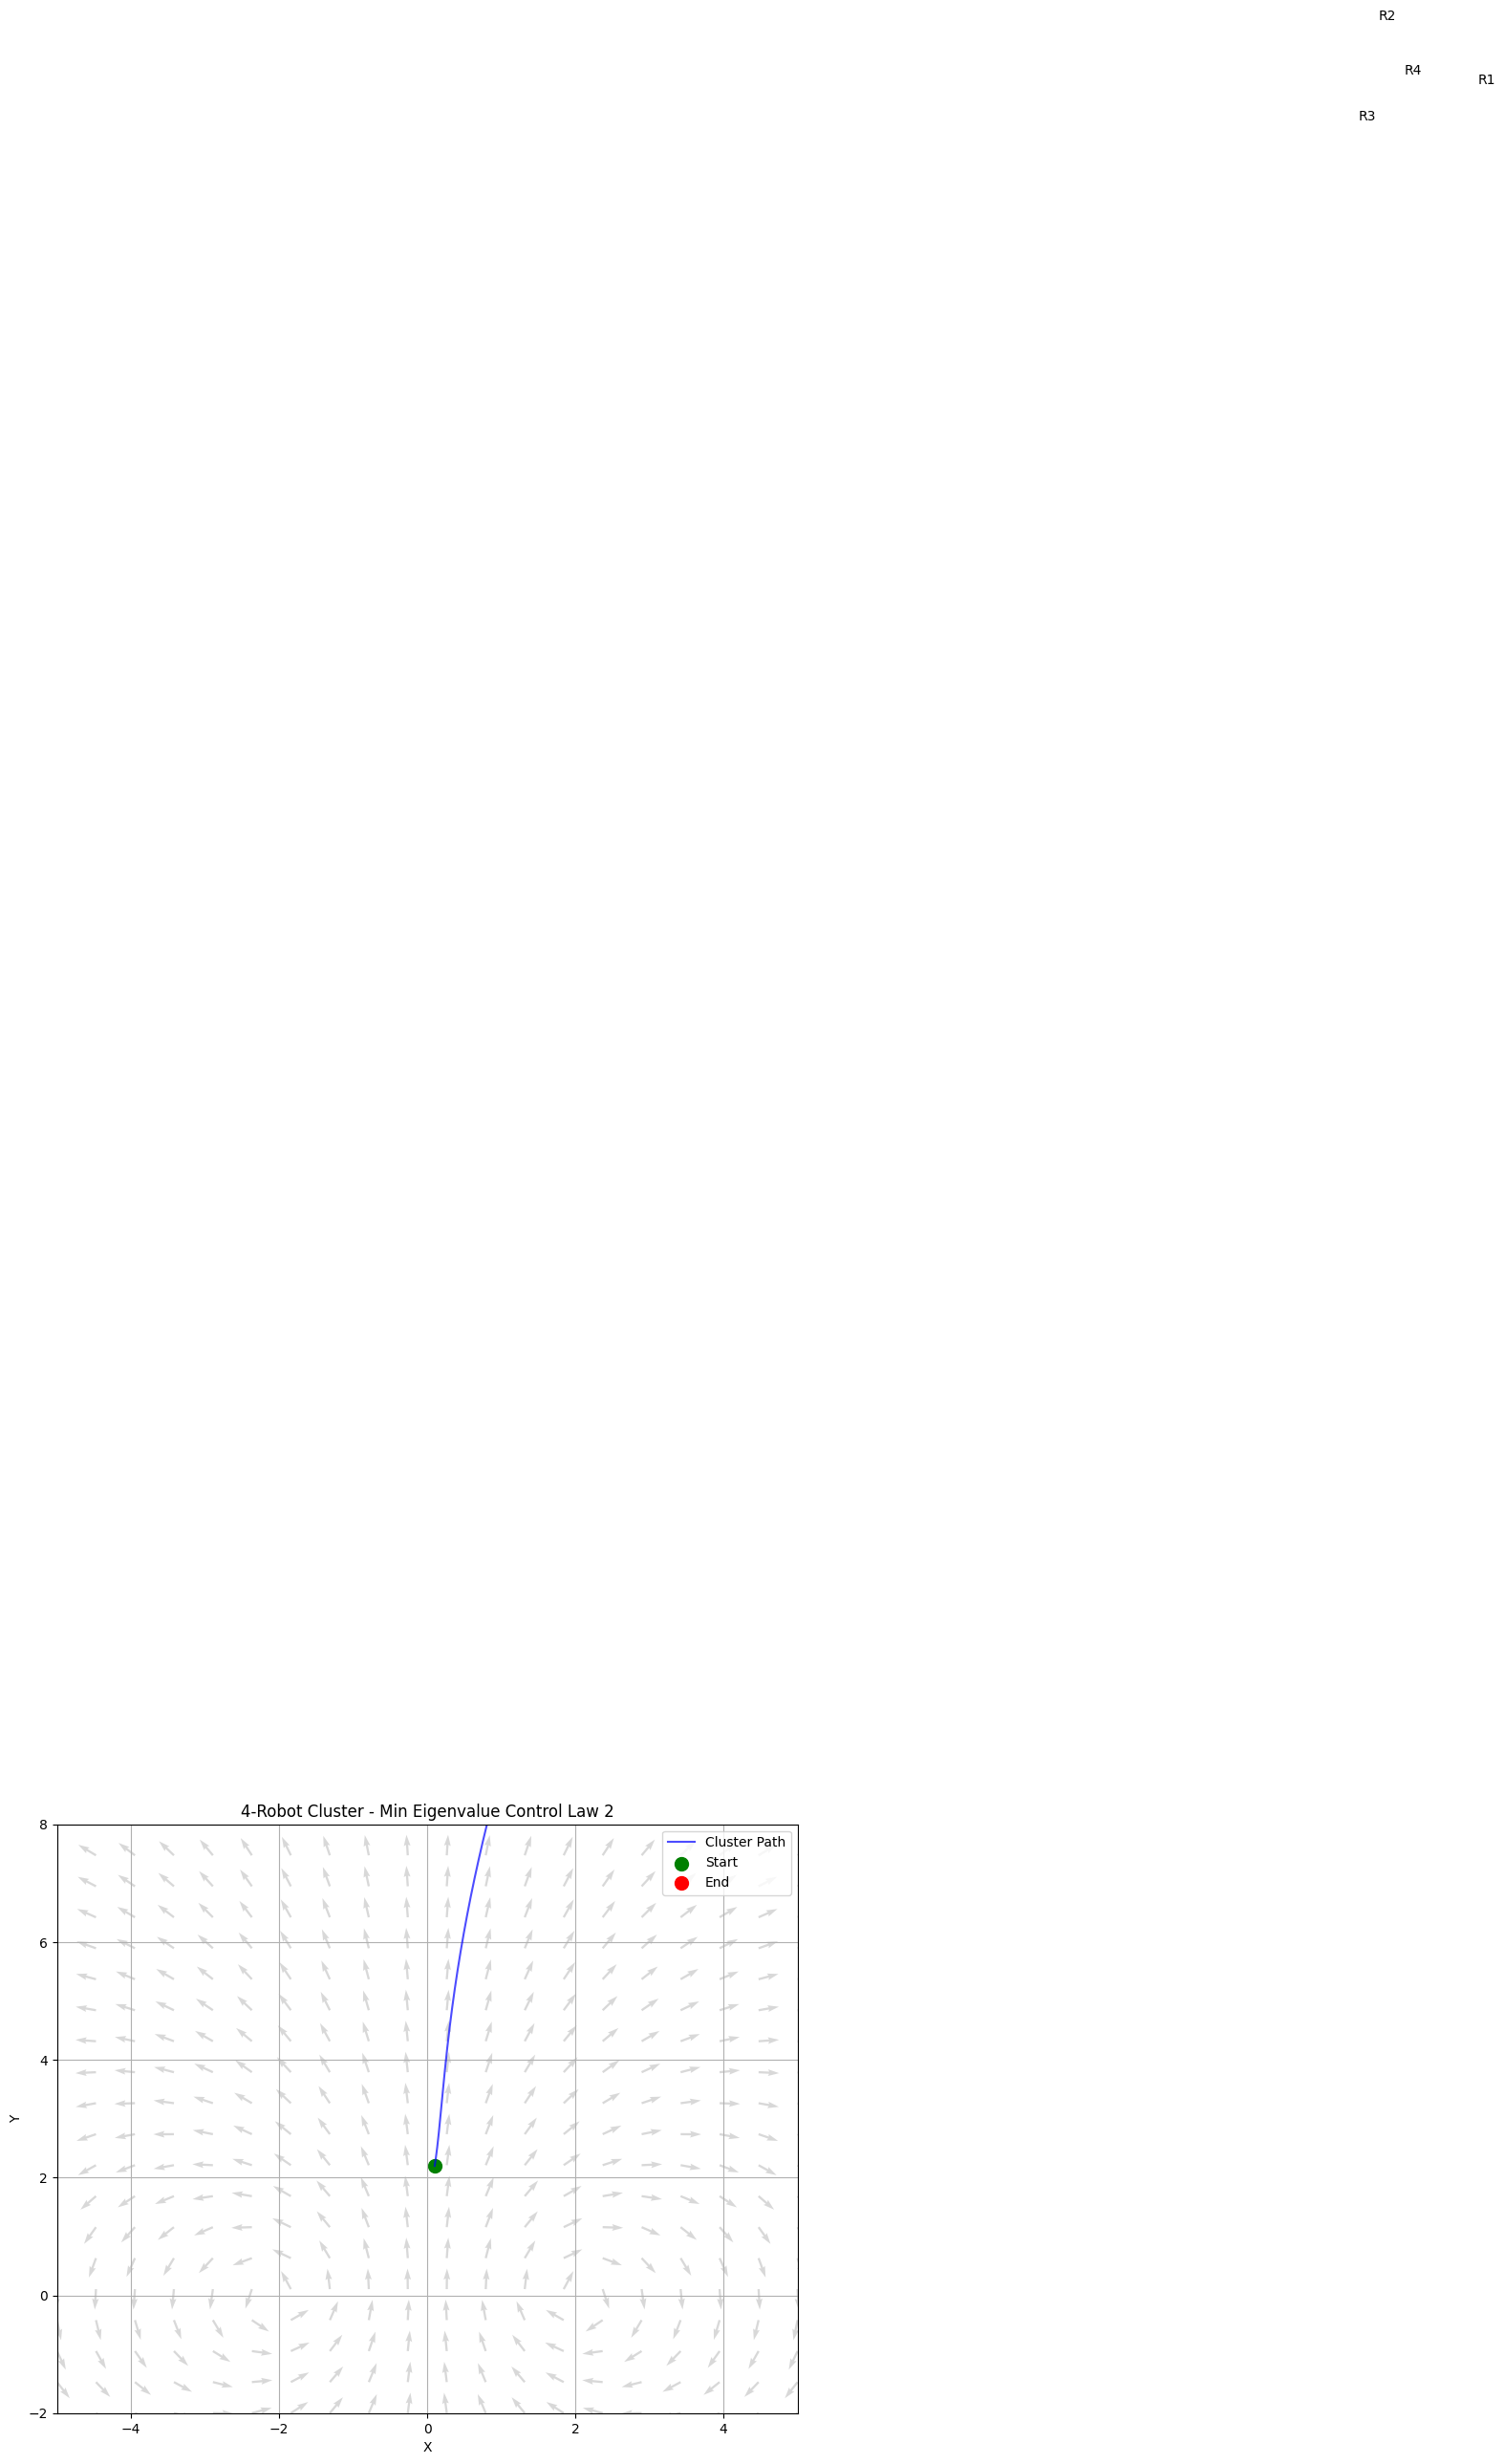

In [102]:
if __name__ == "__main__":
    print("Testing Control Law 1 (Min eigenvalue to specific point)")
    centroid_hist1, robots1, vf1 = simulate_min_eigenvalue_control(
        control_law=1,
        n_steps=600,
        step_size=0.01,
        correction_weight=-0.25,
        verbose=True,
        formation_radius=1
    )
    
    fig1 = visualize_results(centroid_hist1, robots1, vf1, "Law 1")
    plt.show()
    
    print("\n" + "="*50 + "\n")
    print("Testing Control Law 2 (Min eigenvalue gradient)")
    centroid_hist2, robots2, vf2 = simulate_min_eigenvalue_control(
        control_law=2,
        n_steps=600,
        step_size=0.05,
        correction_weight=-0.25,
        verbose=True,
        formation_radius=1
    )
    
    fig2 = visualize_results(centroid_hist2, robots2, vf2, "Law 2")
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class VectorField:
    """Vector field with two counter-rotating vortices."""
    
    def __init__(self):
        self.vortex1_pos = np.array([-2, 0])
        self.vortex2_pos = np.array([2, 0])
        
    def evaluate(self, x, y):
        """Evaluate the vector field at position (x, y)."""
        # Left vortex (counterclockwise)
        x1, y1 = self.vortex1_pos
        vx1 = -(y - y1)
        vy1 = (x - x1)
        
        # Right vortex (clockwise)
        x2, y2 = self.vortex2_pos
        vx2 = (y - y2)
        vy2 = -(x - x2)

        # Combine with distance-based weighting
        d1 = np.sqrt((x - x1)**2 + (y - y1)**2)
        d2 = np.sqrt((x - x2)**2 + (y - y2)**2)
        w1 = 1.0 / (d1**2 + 0.1)
        w2 = 1.0 / (d2**2 + 0.1)
        vx = (vx1 * w1 + vx2 * w2) / (w1 + w2)
        vy = (vy1 * w1 + vy2 * w2) / (w1 + w2)
        return np.array([10*vx, 10*vy])
    
    def jacobian_twosided(self, x, y, h=0.01):
        """Compute Jacobian using two-sided finite differences."""
        fx_plus, fy_plus = self.evaluate(x + h, y)
        fx_minus, fy_minus = self.evaluate(x - h, y)
        fx_yplus, fy_yplus = self.evaluate(x, y + h)
        fx_yminus, fy_yminus = self.evaluate(x, y - h)
        
        J = np.array([
            [(fx_plus - fx_minus) / (2*h), (fx_yplus - fx_yminus) / (2*h)],
            [(fy_plus - fy_minus) / (2*h), (fy_yplus - fy_yminus) / (2*h)]
        ])
        return J

def compute_min_eigenvalue_magnitude(vf, x_range, y_range, resolution=50):
    """Compute minimum eigenvalue magnitude over a grid."""
    x = np.linspace(x_range[0], x_range[1], resolution)
    y = np.linspace(y_range[0], y_range[1], resolution)
    X, Y = np.meshgrid(x, y)
    
    min_eig_mag = np.zeros_like(X)
    
    for i in range(len(y)):
        for j in range(len(x)):
            try:
                # Compute Jacobian at this point
                J = vf.jacobian_twosided(X[i, j], Y[i, j])
                
                # Compute eigenvalues
                eigenvals = np.linalg.eigvals(J)
                
                # Find minimum magnitude eigenvalue
                eig_magnitudes = np.abs(eigenvals)
                #eig_magnitudes = eigenvals

                min_eig_mag[i, j] = np.min(eig_magnitudes)
                
            except:
                # Handle numerical issues near singularities
                min_eig_mag[i, j] = np.nan
    
    return X, Y, min_eig_mag

def plot_min_eigenvalue_magnitude():
    """Create plots showing minimum eigenvalue magnitude."""
    # Initialize vector field
    vf = VectorField()
    
    # Define domain
    x_range = [-5, 5]
    y_range = [-4, 4]
    
    # Compute minimum eigenvalue magnitudes
    print("Computing eigenvalues over grid...")
    X, Y, min_eig_mag = compute_min_eigenvalue_magnitude(vf, x_range, y_range, resolution=60)
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Filled contour plot
    ax1 = axes[0]
    levels = np.linspace(0, np.nanmax(min_eig_mag), 20)
    contourf = ax1.contourf(X, Y, min_eig_mag, levels=levels, cmap='viridis')
    plt.colorbar(contourf, ax=ax1, label='Min |λ|')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title('Minimum Eigenvalue Magnitude (Filled Contours)')
    ax1.set_aspect('equal')
    
    # Mark vortex centers
    ax1.plot(vf.vortex1_pos[0], vf.vortex1_pos[1], 'ro', markersize=8, label='Vortex 1')
    ax1.plot(vf.vortex2_pos[0], vf.vortex2_pos[1], 'ro', markersize=8, label='Vortex 2')
    ax1.legend()
    
    # Plot 2: 3D surface plot
    ax2 = fig.add_subplot(122, projection='3d')
    surf = ax2.plot_surface(X, Y, min_eig_mag, cmap='viridis', alpha=0.8, edgecolor='none')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_zlabel('Min |λ|')
    ax2.set_title('Minimum Eigenvalue Magnitude (3D)')
    plt.colorbar(surf, ax=ax2, shrink=0.5, label='Min |λ|')
    
    plt.tight_layout()
    plt.show()
    
    # Additional analysis
    print(f"Minimum eigenvalue magnitude range: [{np.nanmin(min_eig_mag):.4f}, {np.nanmax(min_eig_mag):.4f}]")
    
    # Find points where minimum eigenvalue magnitude is smallest
    min_indices = np.unravel_index(np.nanargmin(min_eig_mag), min_eig_mag.shape)
    min_x = X[min_indices]
    min_y = Y[min_indices]
    min_val = min_eig_mag[min_indices]
    print(f"Smallest minimum eigenvalue magnitude: {min_val:.6f} at point ({min_x:.3f}, {min_y:.3f})")

# Run the analysis
if __name__ == "__main__":
    plot_min_eigenvalue_magnitude()